<a href="https://colab.research.google.com/github/BaeJinYeong01/-/blob/main/%EC%9E%AC%EA%B3%A0_%EA%B4%80%EB%A6%AC(EOQ).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 재고관리 실습 (기본)


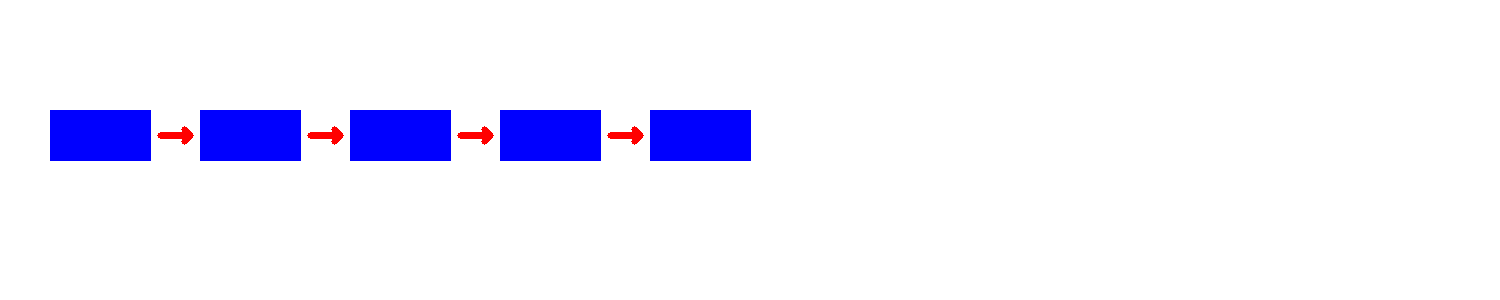

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Necessary import if we are working in Google Colab. Otherwise,
# if will use cv2.imshow(), this import is not required.
from google.colab.patches import cv2_imshow

img = np.zeros((300, 1500, 3), dtype="uint8")
img[:] = (255,255,255)
cv2.rectangle(img, (50,110), (150,160), (255,0,0), (-1))
cv2.arrowedLine(img, (160,135), (190,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (200,110), (300,160), (255,0,0), (-1))
cv2.arrowedLine(img, (310,135), (340,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (350,110), (450,160), (255,0,0), (-1))
cv2.arrowedLine(img, (460,135), (490,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (500,110), (600,160), (255,0,0), (-1))
cv2.arrowedLine(img, (610,135), (640,135), (0,0,255), (5), 8,0,0.3)
cv2.rectangle(img, (650,110), (750,160), (255,0,0), (-1))
cv2_imshow(img)

## 접근 방법

연간 제품 수요가 일정하다고 할 때, 주어진 조건 들을 이용해서 경제적 주문량을 구하고, 병목공정과 조달기간을 이용해서 재주문점을 구합니다. 일반적으로 경제적 주문량을 구하는 문제는 상품을 조달해서 파는 유통업을 대상으로 하고 있으나, 이번 문제는 제조업의 원재료에 그 이론을 적용시켰다는 점에서 함의가 있습니다.

1. 경제적 주문량을 구합니다.

2. 공정별 평균 소요 시간을 구합니다.

3. 병목 공정을 구하고 재주문점을 구합니다.

## 1. 경제적 주문량을 구합니다.

경제적 주문량을 구하는 공식은 root ( 2 X 연간수요량 X 주문비용 / 재고 유지 비용)

데이터를 먼저 읽어들입니다.

In [ ]:
from google.colab import files
uploaded=files.upload()


Saving exercise_4_basic.xlsx to exercise_4_basic.xlsx


In [ ]:
import pandas as pd
import numpy as np
import io

df=pd.read_excel(io.BytesIO(uploaded['exercise_4_basic.xlsx']))

df

df.head()



,A Process,B Process,C Process,D Process,E Process
0,2.893820,2.021257,4.864020,3.010573,4.207683
1,3.273081,1.939095,4.987153,2.989812,3.981068
2,2.962148,2.101597,5.231908,2.983121,3.902457
3,3.002144,2.000724,5.136940,3.007220,3.991817
4,2.804296,2.044791,4.931680,3.047293,3.859356


In [ ]:
# 경제적 주문량 구하기
D = 500
S = 20
H = 0.5

EOQ = ((2*D*S)/H)**0.5
print(EOQ)
## ()**0.5 를 이용해서 경제적 주문량을 구해 보시기 바랍니다.



200.0


In [ ]:
import math

D = 500
S = 20
H = 0.5

EOQ = math.sqrt((2*D*S)/H)
print(EOQ)

# math.sqrt 를 이용해서 경제적 주문량을 구해보시기 바랍니다.

200.0


## 2. 공정별 평균 소요 시간을 구합니다.

각 공정별 평균 소요 시간을 바탕으로 구합니다.


---
A 공정 : 15101008

B 공정 : 25151005

C 공정 : 35101014

D 공정 : 35101015

E 공정 : 35101013

---

In [ ]:
p1 = df.mean()

print(p1)

A Process    2.998900
B Process    2.000327
C Process    4.997402
D Process    3.000251
E Process    3.999428
dtype: float64


## 3. 병목 공정을 구하고 재주문점을 구합니다.

해당 기간 동안의 수요량을 영업일로 나눠서 일별 수요량을 구한 뒤 여기에 10을 곱해서 수요량 기준 재주문점을 구합니다. 이 값과 앞서 구한 공정별 평균 소요시간을 바탕으로 병목공정을 구하고, 병목공정에서의 생산량을 기준으로 재주문점을 구합니다. 이 두 값을 비교해서 작은 값을 기준으로 재주문점을 구합니다.

In [ ]:
# 수요량 기준으로 재주문점 구하기
print(200/40*10)
# 수요량 기준 재주문점 계산
EOQ = 200
working_days = 40
lead_time = 10

daily_demand = EOQ / working_days
reorder_demand = daily_demand * lead_time

print("수요 기준 재주문점:", reorder_demand)

import numpy as np

pi = np.array([2.89, 2.02, 4.86, 3.01, 4.20])

working_hours = 8
bottleneck_time = pi.max()

daily_production = 2 * working_hours / bottleneck_time
reorder_production = daily_production * lead_time

print("생산 기준 재주문점:", reorder_production)

final_reorder_point = min(reorder_demand, reorder_production)

print("최종 재주문점:", final_reorder_point)
# 생산량 기준으로 재주문점 구하기
# 하루에 필요한 평균량을 구해서 10을 구하면 됩니다.
# 8시간을 병목공정평균소요시간으로 나누면 하루에 병목공정을 몇 번 진행하는지 알 수 있고,
# 여기에 원재료 소요량을 곱하면 하루 기준 필요량을 구할 수 있습니다.
print(2*8/p1.max()*10)


50.0
수요 기준 재주문점: 50.0
생산 기준 재주문점: 32.92181069958848
최종 재주문점: 32.92181069958848
32.016638613691725


# 재고관리 실습 (심화)



연간 수요량이 일정하다는 가정은 현실과 너무 동떨어진 가정입니다. 여기서는 수요량이 가변적이라는 가정 하에 경제적 주문량과 재주문점을 구하는 연습을 해 보겠습니다. 단, 공정들은 수요를 만족시키기에 충분하다고 가정한다.

## 접근방법

경제적 주문량을 구하는 방식대로 할 경우 음의 재고가 생길 수 있습니다. (경제적 주문량 모델은 수요량이 일정하다는 가정 하에 만들어진 모형이므로 2달에 한번 꼴로 원재료를 200개씩 주문하면 제품에 대한 수요량이 100개 이상 되어 원재료에 대한 수요량이 200개 이상 되는 시기에는 음의 재고가 발생합니다. (음의 재고라는 개념은 재고가 0 이하라는 의미가 아니라 수요가 있는데도 재고가 없어서 못 파는 상황을 의미합니다.) 이러한 상황에 대해서 PPO 라는 방식으로 접근하려고 합니다. PPO는 주기를 정해서 예측 수요만큼 주문하는 방식입니다. (일종의 JIT와 EOQ를 합친 개념)

1. 조달기간 전에 예측된 다음 기의 수요를 바탕으로 경제적 주문량을 결정합니다.

2. 공정들이 수요를 만족시키기에 충분하다고 가정했기 때문에 병목 공정 자체는 큰 문제가 되지 않습니다. 따라서 재주문점은 조달기간 전의 원재료 재고 수준입니다.

## EOQ 구하기

In [ ]:
# 예측 주문량 (각 2달간)

Demand = [72, 142, 284, 140, 284, 278]

print(sum(Demand))
print(sum(Demand)/len(Demand))
# EOQ
print(Demand)

1200
200.0
[72, 142, 284, 140, 284, 278]


## 재주문점 구하기


In [ ]:
# for문을 이용해서 재주문점을 구해보시오.
# 힌트는 가변 수요량이 약 60일간의 수요이고, 조달기간이 10일이기 때문에,
# 각 2개월마다 수요량이 줄어드는 속도는 일정하다라고 한다면,
# 재주문점은 매번 다를 수 있다.
Demand = [72, 142, 284, 140, 284, 278]

lead_time = 10
period_days = 60

for d in Demand:
    reorder_point = (d / period_days) * lead_time
    print(round(reorder_point,2))


12.0
23.67
47.33
23.33
47.33
46.33
